In [2]:
# Подключение библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройка отображения графиков
%matplotlib inline
plt.style.use('ggplot')

# Загрузка датасета
df = pd.read_csv('/content/sample_data/train.csv')

# Первый взгляд на данные
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Количество строк и столбцов
print("Размер датасета (строки, столбцы):", df.shape)

# Названия всех столбцов
print("\nСтолбцы:")
print(df.columns.tolist())

# Типы данных столбцов
print("\nТипы данных:")
print(df.dtypes)

# Общая информация
df.info()

Размер датасета (строки, столбцы): (891, 12)

Столбцы:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  

In [4]:
# 1. Количество пассажиров каждого класса
print("Пассажиры по классам:")
print(df['Pclass'].value_counts().sort_index())

# 2. Количество мужчин и женщин
print("\nПассажиры по полу:")
print(df['Sex'].value_counts())

# 3. Разделение на возрастные группы
bins = [0, 12, 18, 30, 50, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые (19-30)',
          'Взрослые (31-50)', 'Пожилые (50+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print("\nВозрастные группы:")
print(df['AgeGroup'].value_counts().sort_index())

# 4. Средний возраст
print("\nСредний возраст пассажиров:", round(df['Age'].mean(), 2))

# 5. Медианный возраст
print("Медианный возраст:", df['Age'].median())

# 6. Средняя стоимость билета
print("Средняя стоимость билета:", round(df['Fare'].mean(), 2))

Пассажиры по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Пассажиры по полу:
Sex
male      577
female    314
Name: count, dtype: int64

Возрастные группы:
AgeGroup
Дети (0-12)           69
Подростки (13-18)     70
Молодые (19-30)      270
Взрослые (31-50)     241
Пожилые (50+)         64
Name: count, dtype: int64

Средний возраст пассажиров: 29.7
Медианный возраст: 28.0
Средняя стоимость билета: 32.2


In [5]:
# 1. Средняя стоимость билета по классам
print("Средняя стоимость билета по классам:")
print(df.groupby('Pclass')['Fare'].mean().round(2))

# 2. Средний возраст по классам
print("\nСредний возраст по классам:")
print(df.groupby('Pclass')['Age'].mean().round(2))

# 3. Количество мужчин и женщин в каждом классе
print("\nПол по классам:")
print(df.groupby(['Pclass', 'Sex']).size().unstack())

# 4. В каком классе больше всего пассажиров
print("\nСамый многочисленный класс:",
      df['Pclass'].value_counts().idxmax())

# 5. Самый дорогой билет
max_fare_row = df.loc[df['Fare'].idxmax()]
print("\nСамый дорогой билет:")
print(max_fare_row[['Name', 'Pclass', 'Age', 'Sex', 'Fare', 'Survived']])

Средняя стоимость билета по классам:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

Средний возраст по классам:
Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64

Пол по классам:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347

Самый многочисленный класс: 3

Самый дорогой билет:
Name        Ward, Miss. Anna
Pclass                     1
Age                     35.0
Sex                   female
Fare                512.3292
Survived                   1
Name: 258, dtype: object


In [6]:
# 1. Общее количество выживших и погибших
print("Выживаемость (0 - погиб, 1 - выжил):")
print(df['Survived'].value_counts())
print("Доля выживших:", round(df['Survived'].mean() * 100, 2), "%")

# 2. Выживаемость по полу
print("\nВыживаемость по полу:")
print(df.groupby('Sex')['Survived'].mean().round(3) * 100)

# 3. Выживаемость по полу и классу
print("\nВыживаемость по классу и полу (%):")
print((df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100).round(1))

# 4. Группа с наибольшей долей выживших
surv_by_group = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
best_group = surv_by_group.idxmax()
print("\nГруппа с наибольшей долей выживших:", best_group,
      "—", round(surv_by_group.max() * 100, 1), "%")

Выживаемость (0 - погиб, 1 - выжил):
Survived
0    549
1    342
Name: count, dtype: int64
Доля выживших: 38.38 %

Выживаемость по полу:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

Выживаемость по классу и полу (%):
Pclass  Sex   
1       female    96.8
        male      36.9
2       female    92.1
        male      15.7
3       female    50.0
        male      13.5
Name: Survived, dtype: float64

Группа с наибольшей долей выживших: (np.int64(1), 'female') — 96.8 %


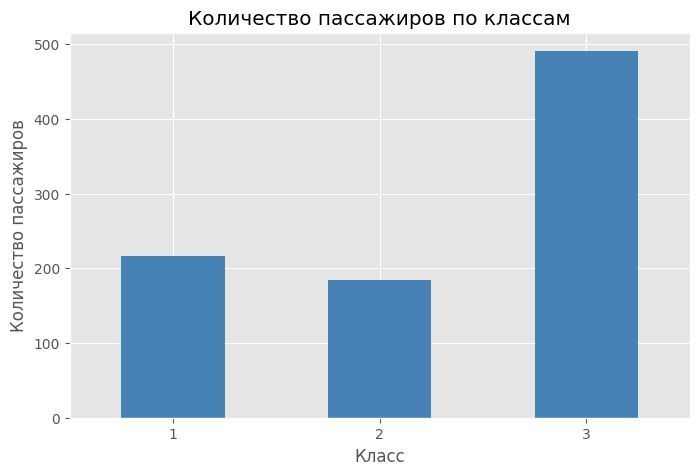

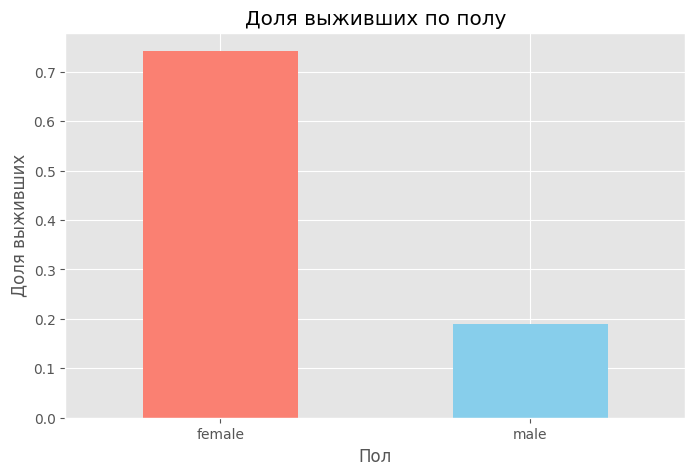

<Figure size 800x500 with 0 Axes>

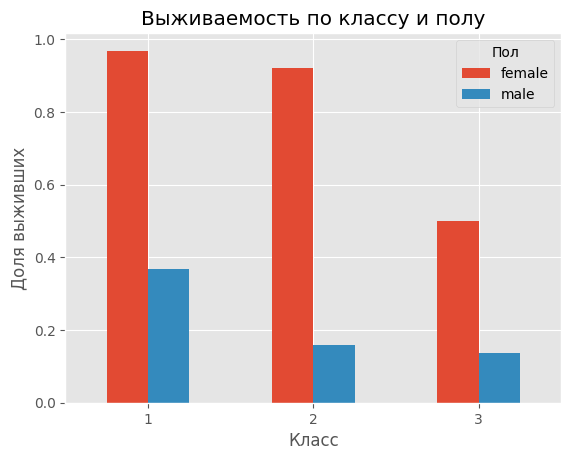

In [7]:
# 1. График количества пассажиров по классам
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.show()

# 2. График выживаемости по полу
plt.figure(figsize=(8, 5))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.show()

# Дополнительно: выживаемость по классу и полу
plt.figure(figsize=(8, 5))
df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().plot(kind='bar')
plt.title('Выживаемость по классу и полу')
plt.xlabel('Класс')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.legend(title='Пол')
plt.show()

Выживаемость по размеру семьи:
             mean  count
FamilySize              
0           0.304    537
1           0.553    161
2           0.578    102
3           0.724     29
4           0.200     15
5           0.136     22
6           0.333     12
7           0.000      6
10          0.000      7


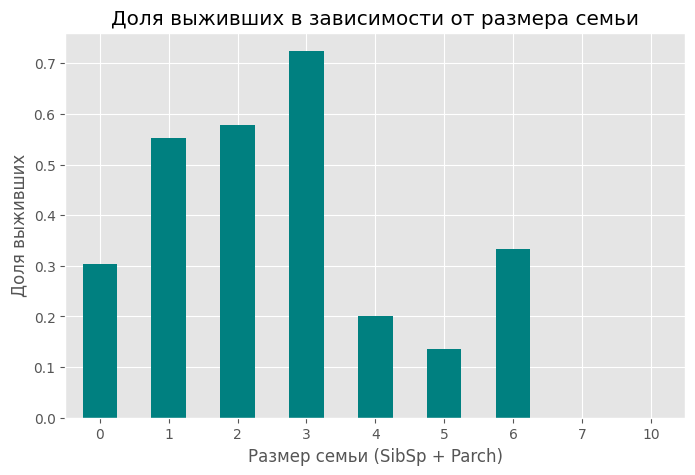

In [8]:
# Создаём признак "FamilySize"
df['FamilySize'] = df['SibSp'] + df['Parch']

# Выживаемость в зависимости от размера семьи
print("Выживаемость по размеру семьи:")
print(df.groupby('FamilySize')['Survived'].agg(['mean', 'count']).round(3))

# Визуализация
plt.figure(figsize=(8, 5))
df.groupby('FamilySize')['Survived'].mean().plot(kind='bar', color='teal')
plt.title('Доля выживших в зависимости от размера семьи')
plt.xlabel('Размер семьи (SibSp + Parch)')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.show()